# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# inisialisasi  file csv

In [2]:
data = pd.read_csv('dirty_cafe_sales.csv')
print(data)
print('data info',data.info())
print('data description',data.describe())

     Transaction ID      Item Quantity Price Per Unit Total Spent  \
0       TXN_1961373    Coffee        2            2.0         4.0   
1       TXN_4977031      Cake        4            3.0        12.0   
2       TXN_4271903    Cookie        4            1.0       ERROR   
3       TXN_7034554     Salad        2            5.0        10.0   
4       TXN_3160411    Coffee        2            2.0         4.0   
...             ...       ...      ...            ...         ...   
9995    TXN_7672686    Coffee        2            2.0         4.0   
9996    TXN_9659401       NaN        3            NaN         3.0   
9997    TXN_5255387    Coffee        4            2.0         8.0   
9998    TXN_7695629    Cookie        3            NaN         3.0   
9999    TXN_6170729  Sandwich        3            4.0        12.0   

      Payment Method  Location Transaction Date  
0        Credit Card  Takeaway       2023-09-08  
1               Cash  In-store       2023-05-16  
2        Credit Card 

# Changes to numeric

In [3]:
data['Quantity'] = pd.to_numeric(data['Quantity'], errors='coerce')
data['Price Per Unit'] = pd.to_numeric(data['Price Per Unit'], errors='coerce')
data['Total Spent'] = pd.to_numeric(data['Total Spent'], errors='coerce')


print('Data types after conversion:')
print(data.dtypes)

Data types after conversion:
Transaction ID       object
Item                 object
Quantity            float64
Price Per Unit      float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
dtype: object


# check missing value

In [4]:
print(data.isnull().sum())

Transaction ID         0
Item                 333
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64


# Metode1 check missing value: Drop Data

In [6]:
df_drop = data.dropna()
print('Jumlah data sebelum di drop', len(data))
print('Jumlah data setelah di drop', len(df_drop))
print(df_drop)

Jumlah data sebelum di drop 10000
Jumlah data setelah di drop 4096
     Transaction ID      Item  Quantity  Price Per Unit  Total Spent  \
0       TXN_1961373    Coffee       2.0             2.0          4.0   
1       TXN_4977031      Cake       4.0             3.0         12.0   
3       TXN_7034554     Salad       2.0             5.0         10.0   
4       TXN_3160411    Coffee       2.0             2.0          4.0   
6       TXN_4433211   UNKNOWN       3.0             3.0          9.0   
...             ...       ...       ...             ...          ...   
9979    TXN_9933628  Smoothie       5.0             4.0         20.0   
9986    TXN_2858441  Sandwich       2.0             4.0          8.0   
9991    TXN_3897619  Sandwich       3.0             4.0         12.0   
9992    TXN_2739140  Smoothie       4.0             4.0         16.0   
9999    TXN_6170729  Sandwich       3.0             4.0         12.0   

      Payment Method  Location Transaction Date  
0        Credit Ca

# Metode2 missing value: Imputasi numerik dan median

In [7]:
data_impute = data.copy()

numeric_cols = ['Quantity', 'Price Per Unit', 'Total Spent']

for col in numeric_cols:
    data_impute[col] = data_impute[col].fillna(data_impute[col].median())
    

print("Missing valees setelah di imputasi")
print(data_impute[numeric_cols].isnull().sum())

Missing valees setelah di imputasi
Quantity          0
Price Per Unit    0
Total Spent       0
dtype: int64


# Metode Duplicate Data1: delete all 

In [10]:
data_dup_all = data_impute.drop_duplicates()
print('Jumlah data sebelum di drop duplicate', len(df_drop))
print('Jumlah data setelah di drop duplicate', len(data_dup_all))
print(data_dup_all)

Jumlah data sebelum di drop duplicate 4096
Jumlah data setelah di drop duplicate 10000
     Transaction ID      Item  Quantity  Price Per Unit  Total Spent  \
0       TXN_1961373    Coffee       2.0             2.0          4.0   
1       TXN_4977031      Cake       4.0             3.0         12.0   
2       TXN_4271903    Cookie       4.0             1.0          8.0   
3       TXN_7034554     Salad       2.0             5.0         10.0   
4       TXN_3160411    Coffee       2.0             2.0          4.0   
...             ...       ...       ...             ...          ...   
9995    TXN_7672686    Coffee       2.0             2.0          4.0   
9996    TXN_9659401       NaN       3.0             3.0          3.0   
9997    TXN_5255387    Coffee       4.0             2.0          8.0   
9998    TXN_7695629    Cookie       3.0             3.0          3.0   
9999    TXN_6170729  Sandwich       3.0             4.0         12.0   

      Payment Method  Location Transaction Date 

# Metode Duplicate Data 2

In [13]:
data_dup_id = data_impute.drop_duplicates(subset=['Transaction ID'])
print('Jumlah data sebelum di drop duplicate berdasarkan Transaction ID', len(df_drop))
print('Jumlah data setelah di drop duplicate berdasarkan Transaction ID', len(data_dup_id))
print(data_dup_id)

Jumlah data sebelum di drop duplicate berdasarkan Transaction ID 4096
Jumlah data setelah di drop duplicate berdasarkan Transaction ID 10000
     Transaction ID      Item  Quantity  Price Per Unit  Total Spent  \
0       TXN_1961373    Coffee       2.0             2.0          4.0   
1       TXN_4977031      Cake       4.0             3.0         12.0   
2       TXN_4271903    Cookie       4.0             1.0          8.0   
3       TXN_7034554     Salad       2.0             5.0         10.0   
4       TXN_3160411    Coffee       2.0             2.0          4.0   
...             ...       ...       ...             ...          ...   
9995    TXN_7672686    Coffee       2.0             2.0          4.0   
9996    TXN_9659401       NaN       3.0             3.0          3.0   
9997    TXN_5255387    Coffee       4.0             2.0          8.0   
9998    TXN_7695629    Cookie       3.0             3.0          3.0   
9999    TXN_6170729  Sandwich       3.0             4.0         12.

# Metode 1 Outlier

# Deteksi Outlier

In [14]:
Q1 = data_impute['Total Spent'].quantile(0.25)
Q3 = data_impute['Total Spent'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_iqr = data_impute[
    (data_impute['Total Spent'] < lower) |
    (data_impute['Total Spent'] > upper)
]

print("Jumlah outlier (IQR):", len(outlier_iqr))

Jumlah outlier (IQR): 259


# Handling Outlier

In [15]:
data_iqr_clean = data_impute[
    (data_impute['Total Spent'] >= lower) &
    (data_impute['Total Spent'] <= upper)
]

print("Jumlah data setelah menghapus outlier (IQR):", len(data_iqr_clean))

Jumlah data setelah menghapus outlier (IQR): 9741


# Metode 2 Z-Score

# Deteksi Outlier Z-Score

In [ ]:
from scipy import stats
ZScoress = np.abs(stats.zscore(data_impute['Total Spent']))

outlier_z = data_impute[ZScoress > 2]

print("Jumlah outlier (Z-Score):", len(outlier_z))

Jumlah outlier (Z-Score): 259


# Handling Z-Scores

In [ ]:
data_z_clean = data_impute[ZScoress <= 3]

print("Jumlah data setelah menghapus outlier (Z-Score):", len(data_z_clean))    

Jumlah data setelah menghapus outlier (Z-Score): 0


# Visualisasi 

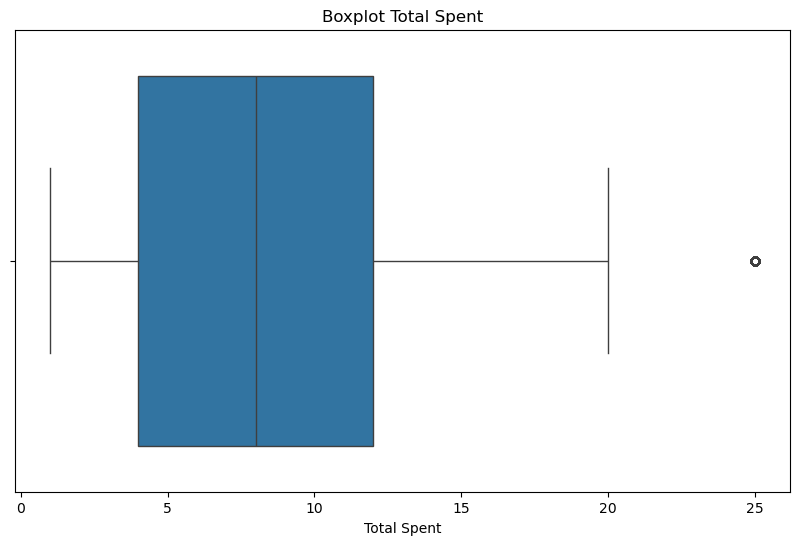

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=data_impute['Total Spent'])
plt.title('Boxplot Total Spent')
plt.show()

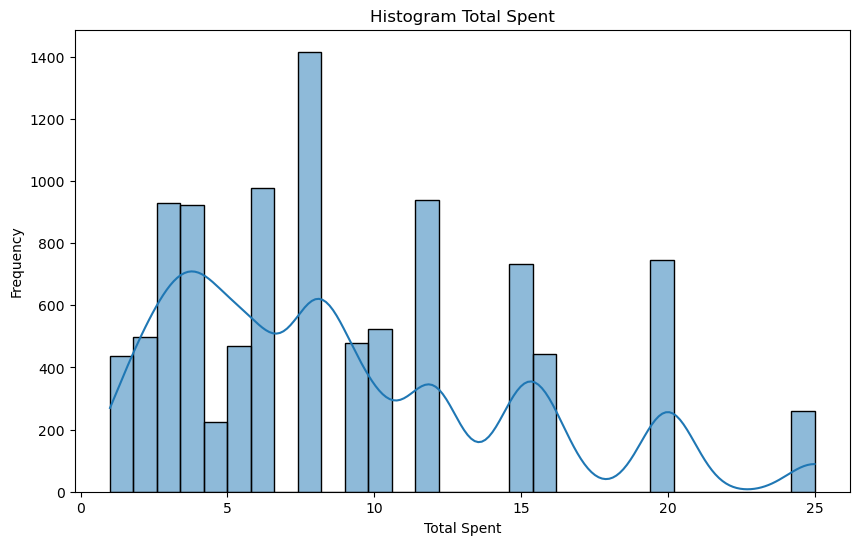

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(data=data_impute, x='Total Spent', bins=30, kde=True)
plt.xlabel('Total Spent')
plt.ylabel('Frequency')
plt.title('Histogram Total Spent')
plt.show()